# <a id='toc1_'></a>[Project of Analysis for New lines of Books](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Project of Analysis for New lines of Books](#toc1_)    
  - [Introduccion](#toc1_1_)    
  - [Objetivo general:](#toc1_2_)    
    - [Objetivos específicos:](#toc1_2_1_)    
  - [Descripcion de los datos relacionados con el proyecto:](#toc1_3_)    
  - [Conexion a la base de datos SQL](#toc1_4_)    
  - [Analisis Exploratorio de los datos](#toc1_5_)    
    - [Comentarios](#toc1_5_1_)    
  - [Libros publicados después del 1 de enero de el año 2000](#toc1_6_)    
    - [Comentarios](#toc1_6_1_)    
  - [Número de reseñas de usuarios y calificación promedio para cada libro.](#toc1_7_)    
    - [Comentarios](#toc1_7_1_)    
  - [Editorial que ha publicado el mayor número de libros con más de 50 páginas (Diferenciación Folletos y Libros)](#toc1_8_)    
    - [Comentarios](#toc1_8_1_)    
  - [Autores con la calificación promedio más alta por libros](#toc1_9_)    
    - [Comentarios](#toc1_9_1_)    
  - [Número promedio de reseñas de texto entre los usuarios que calificaron más de 50 libros](#toc1_10_)    
    - [Comentarios](#toc1_10_1_)    
- [Conclusiones](#toc2_)    
- [Propuesta de valor para un nuevo producto digital](#toc3_)    
    - [Descripción general](#toc3_1_1_)    
    - [Objetivos del nuevo producto](#toc3_1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Introduccion](#toc0_)
El mercado de aplicaciones para lectores ha crecido significativamente en los últimos años, especialmente a raíz de la pandemia, misma situacion que incentivó a más personas a buscar alternativas de entretenimiento en casa. Este proyecto se centra en el análisis de una base de datos real de una plataforma de libros, con el fin de extraer información relevante sobre el comportamiento de los usuarios, la popularidad de los libros y el desempeño de autores y editoriales. Los resultados obtenidos servirán como base para la propuesta de valor de un nuevo producto digital que busca mejorar la experiencia de los usuarios a su vez que potenciar la oferta de la plataforma.

## <a id='toc1_2_'></a>[Objetivo general:](#toc0_)

- Analizar la base de datos de la plataforma para identificar tendencias y patrones relevantes que contribuyan al desarrollo de una propuesta de valor para un nuevo producto digital.
### <a id='toc1_2_1_'></a>[Objetivos específicos:](#toc0_)

 - Explorar y comprender la estructura y el contenido de las tablas disponibles en la base de datos.
 - Determinar la cantidad de libros publicados después del 1 de enero de 2000.
 - Calcular el número de reseñas de usuarios y la calificación promedio para cada libro.
 - Identificar la editorial que ha publicado la mayor cantidad de libros con más de 50 páginas.
 - Determinar el autor con la calificación promedio más alta, considerando solo libros con al menos 50 calificaciones.
 - Calcular el número promedio de reseñas de texto entre los usuarios que han calificado más de 50 libros.

## <a id='toc1_3_'></a>[Descripcion de los datos relacionados con el proyecto:](#toc0_)
``books:``
Contiene datos sobre libros:

- book_id — identificación del libro
- author_id — identificación del autor o autora
- title — título
- num_pages — número de páginas
- publication_date — fecha de la publicación
- publisher_id — identificación de la editorial

``authors:``
Contiene datos sobre autores:

- author_id — identificación del autor o autora
- author — el autor o la autora

``publishers:``
Contiene datos sobre editoriales:

- publisher_id — identificación de la editorial
- publisher — la editorial

``ratings:``
Contiene datos sobre las calificaciones de usuarios:

- rating_id — identificación de la calificación
- book_id — identificación del libro
- username — el nombre del usuario que revisó el libro
- rating — calificación

``reviews:``
Contiene datos sobre las reseñas de los y las clientes:

- review_id — identificación de la reseña
- book_id — identificación del libro
- username — el nombre del usuario que revisó el libro
- text — el texto de la reseña

In [867]:
# Importacion de librerias
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine


## <a id='toc1_4_'></a>[Conexion a la base de datos SQL](#toc0_)

In [868]:
# Establecer la conexión a la base de datos PostgreSQL

db_config = {
 'user': 'practicum_student', # username
 'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7', # password
 'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
 'port': 5432, # connection port
 'db': 'data-analyst-final-project-db' # the name of the database
 }
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(db_config['user'],
                                                         db_config['pwd'],
                                                         db_config['host'],
                                                         db_config['port'],
                                                         db_config['db'])
engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [869]:
# Funcion para obtener los datos de acuerdo a la consulta SQL

def get_data(query):
    with engine.connect() as connection:
        return pd.read_sql(query, connection)

## <a id='toc1_5_'></a>[Analisis Exploratorio de los datos](#toc0_)


In [870]:
# Carga de dataset books

books= get_data('SELECT * FROM books')
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_id           1000 non-null   int64 
 1   author_id         1000 non-null   int64 
 2   title             1000 non-null   object
 3   num_pages         1000 non-null   int64 
 4   publication_date  1000 non-null   object
 5   publisher_id      1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB


In [871]:
# Muestra de registros aleatorios del dataset
print(books.sample(5))

     book_id  author_id                                      title  num_pages  \
68        69        257       Along Came a Spider (Alex Cross  #1)        449   
382      383         32  Lasher (Lives of the Mayfair Witches  #2)        400   
320      321        197                        Homage to Catalonia        232   
628      629        413  The Amazing Adventures of Kavalier & Clay        639   
992      993         80                                      Women        291   

    publication_date  publisher_id  
68        2003-08-01           116  
382       2004-11-04            21  
320       1980-10-22           124  
628       2001-08-25           223  
992       2014-07-29            99  


In [872]:
# Carga de dataset authors
authors= get_data('SELECT * FROM authors')
authors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   author_id  636 non-null    int64 
 1   author     636 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.1+ KB


In [873]:
# Muestra de registros aleatorios de authors
print(authors.sample(5))

     author_id                                             author
333        334                                      Karen Cushman
485        486                         Rachel Cohn/David Levithan
266        267                                      Jane Hamilton
626        627  William Shakespeare/Barbara A. Mowat/Paul Wers...
445        446                       Nicholas Sparks/Micah Sparks


In [874]:
# Carga de dataset publishers
publishers= get_data('SELECT * FROM publishers')
publishers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   publisher_id  340 non-null    int64 
 1   publisher     340 non-null    object
dtypes: int64(1), object(1)
memory usage: 5.4+ KB


In [875]:
# Muestra de registros aleatorios de authors
print(authors.sample(5))

     author_id                                             author
349        350                      Kimon Nicolaides/Mamie Harmon
195        196                 George Orwell/Christopher Hitchens
362        363  Leo Tolstoy/Henry Gifford/Aylmer Maude/Louise ...
269        270                                    Janet Evanovich
536        537                              Sophocles/J.E. Thomas


In [876]:
# Carga de dataset ratings
ratings= get_data('SELECT * FROM ratings')
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6456 entries, 0 to 6455
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   rating_id  6456 non-null   int64 
 1   book_id    6456 non-null   int64 
 2   username   6456 non-null   object
 3   rating     6456 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 201.9+ KB


In [877]:
# Muestra de  registros aleatorios de ratings
print(ratings.sample(5))

      rating_id  book_id       username  rating
6073       6074      948        awright       4
3419       3420      545  briannachavez       3
1151       1152      195       joseph14       5
4897       4898      750     brianwoods       4
5100       5101      785         yweeks       3


In [878]:
# Carga del dataset reviews
reviews=get_data('SELECT * FROM reviews')
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2793 entries, 0 to 2792
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review_id  2793 non-null   int64 
 1   book_id    2793 non-null   int64 
 2   username   2793 non-null   object
 3   text       2793 non-null   object
dtypes: int64(2), object(2)
memory usage: 87.4+ KB


In [879]:
# Muestra de datos aleatorios de reviews
print(reviews.sample(5))

      review_id  book_id     username  \
699         698      259  carlsonbrad   
2762       2763      990     robert56   
1050       1051      386  sfitzgerald   
2635       2636      945    richard89   
1900       1898      688      fharris   

                                                   text  
699   Admit put spring suggest. Best scientist catch...  
2762  Project two indeed hospital and science offici...  
1050                Stop house somebody bar land glass.  
2635  Certainly surface give it drop time. Another o...  
1900  I everybody any station everyone. Brother ball...  


### <a id='toc1_5_1_'></a>[Comentarios](#toc0_)
- Despues de cargar los datos y visualizar cada dataset, se puede observar que cada tabla tiene una estructura clara y bien definida, con identificadores únicos para cada registro.

- A si mismo  la estructura de las tablas permite realizar un análisis detallado de la relación entre libros, autores, editoriales, calificaciones y reseñas. Esto facilita la identificación de tendencias y patrones en el comportamiento de los usuarios, la popularidad de los libros y el desempeño de autores y editoriales.

## <a id='toc1_6_'></a>[Libros publicados después del 1 de enero de el año 2000](#toc0_)

In [880]:
# Consulta de libros publicados después del 1 de enero de el año 2000

books_after_2000 = get_data('''SELECT COUNT(*) as books_after_2000 
                            FROM books 
                            WHERE publication_date > \'2000-01-01\';''')
print(f'Cantidad de libros despues del 1 de enero del 2000 → ({books_after_2000.iloc[0, 0]} publicaciones)')

Cantidad de libros despues del 1 de enero del 2000 → (819 publicaciones)


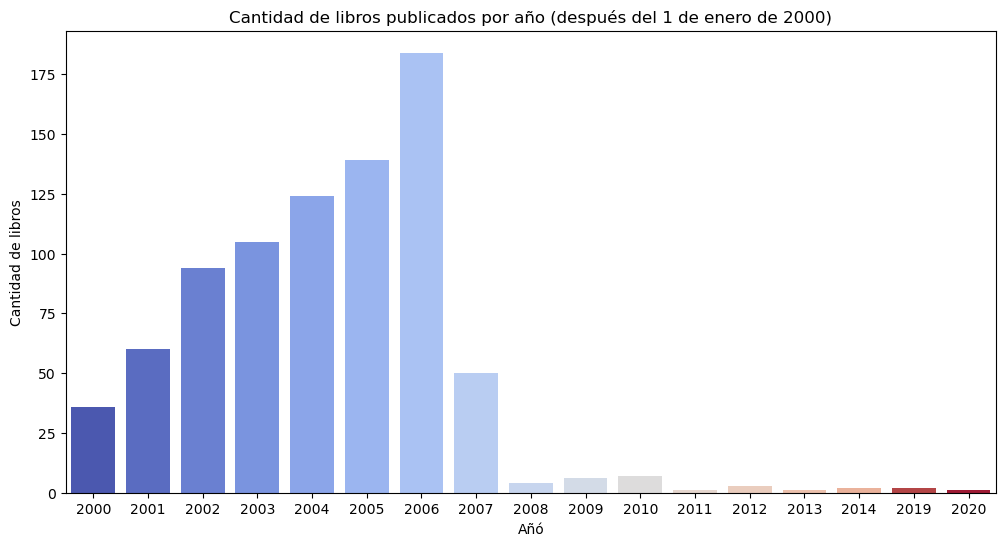

In [881]:

# Filtrado de libros publicados después del 1 de enero de el año 2000
books_after_2000=get_data('''SELECT *
                            FROM books 
                            WHERE publication_date > \'2000-01-01\';''')

books_after_2000['publication_year']= pd.to_datetime(books_after_2000['publication_date']).dt.year
books_count_year = books_after_2000['publication_year'].value_counts().sort_index()
books_count_year= books_count_year.rename_axis('Year').reset_index(name='Count')

# Visualización de la cantidad de libros publicados por año

plt.figure(figsize=(12,6))
sns.barplot(data=books_count_year,x='Year', y='Count', palette='coolwarm',hue='Year', legend=False)
plt.title('Cantidad de libros publicados por año (después del 1 de enero de 2000)')
plt.xlabel('Añó')
plt.ylabel('Cantidad de libros')
plt.show()




### <a id='toc1_6_1_'></a>[Comentarios](#toc0_)
- A partir del nuevo siglo dinde se efectua el filtrado se resalta la mayoria de los libros publicados, lo que indica un crecimiento significativo en la producción editorial en este periodo.
- La consulta realizada permite identificar la cantidad de libros publicados después del 1 de enero de 2000, donde se aprecia la publicacion de `819` nuevos libros. 
- Al apreciar el numero de lanzamientos de libros por año apartir de esta fecha, se tiene un comportamiento creciente casi lineal hasta el año 2006, donde se observa un aumento significativo en la cantidad de libros publicados. A partir de 2007, se observa una caida bastante significativa de mas de un 70% de las publicaciones, motivo por el cual se recomienda investigar las causas de esta disminución, ya que puede estar relacionada con cambios en la industria editorial, la aparición de nuevas plataformas digitales o cambios en las preferencias de los lectores. 

## <a id='toc1_7_'></a>[Número de reseñas de usuarios y calificación promedio para cada libro.](#toc0_)


In [882]:
# Consulta de número de reseñas de usuarios y calificación promedio para cada libro
reviews_summary = get_data('''SELECT books.book_id,
                            books.title,
                            COUNT(reviews.review_id) AS num_reviews,
                            AVG(ratings.rating) AS avg_rating
                            FROM books
                            LEFT JOIN reviews ON books.book_id = reviews.book_id
                            LEFT JoIN ratings ON books.book_id = ratings.book_id
                            GROUP BY books.book_id, books.title;''')

# Top 10 libros con más reseñas
top10_reviews=reviews_summary.sort_values(by='num_reviews', ascending=False).head(10).reset_index(drop=True)
print(top10_reviews)



   book_id                                              title  num_reviews  \
0      948                            Twilight (Twilight  #1)         1120   
1      750                The Hobbit  or There and Back Again          528   
2      673                             The Catcher in the Rye          516   
3      302  Harry Potter and the Prisoner of Azkaban (Harr...          492   
4      299  Harry Potter and the Chamber of Secrets (Harry...          480   
5       75               Angels & Demons (Robert Langdon  #1)          420   
6      301  Harry Potter and the Order of the Phoenix (Har...          375   
7      779  The Lightning Thief (Percy Jackson and the Oly...          372   
8      722  The Fellowship of the Ring (The Lord of the Ri...          370   
9       79                                        Animal Farm          370   

   avg_rating  
0    3.662500  
1    4.125000  
2    3.825581  
3    4.414634  
4    4.287500  
5    3.678571  
6    4.186667  
7    4.080645

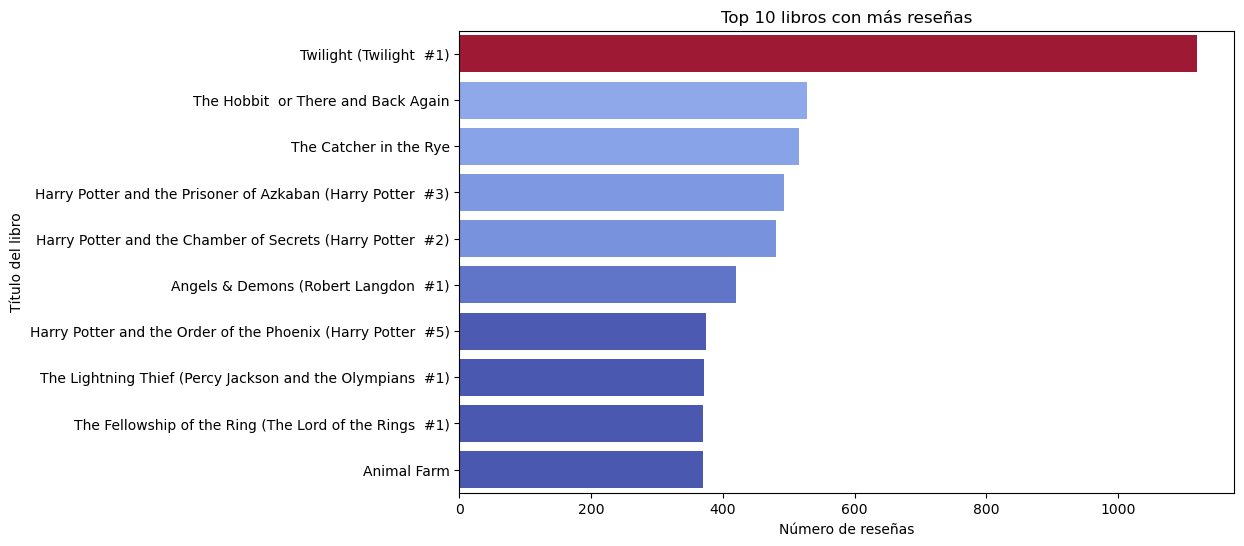

In [883]:
# Grafico Top 10 libros con más reseñas
plt.figure(figsize=(10,6))
sns.barplot(data=top10_reviews, x='num_reviews', y='title', palette='coolwarm', hue='num_reviews', legend=False)
plt.title('Top 10 libros con más reseñas')
plt.xlabel('Número de reseñas')
plt.ylabel('Título del libro')
plt.show()

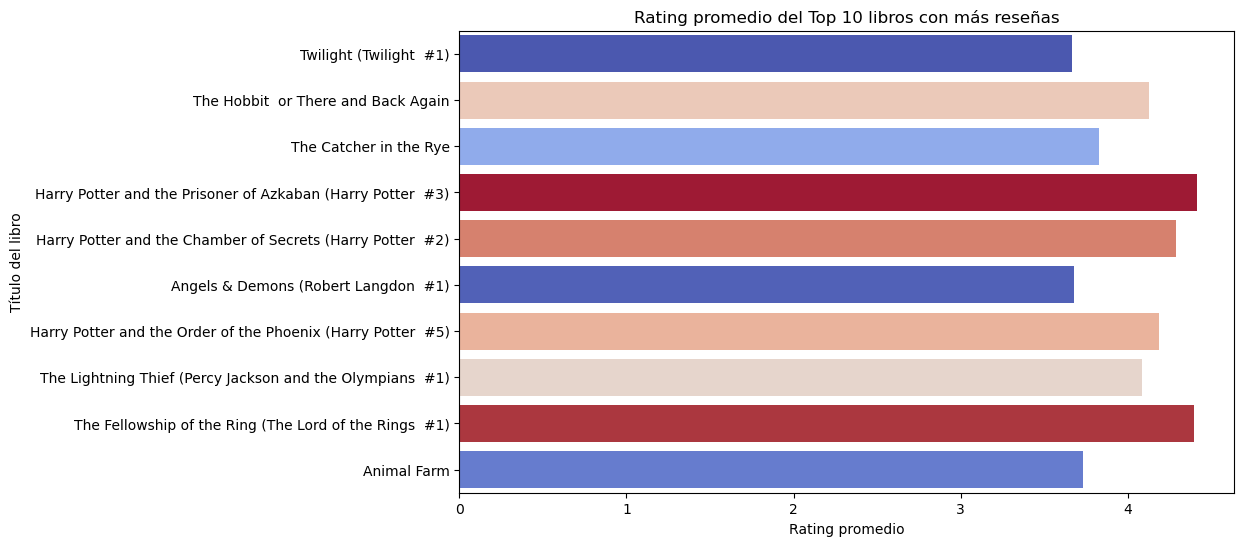

In [884]:
# Grafico de rating promedio del Top 10 libros con más reseñas
plt.figure(figsize=(10,6))
sns.barplot(data=top10_reviews, x='avg_rating', y='title', palette='coolwarm', hue='avg_rating', legend=False)
plt.title('Rating promedio del Top 10 libros con más reseñas')
plt.xlabel('Rating promedio')
plt.ylabel('Título del libro')
plt.show()

### <a id='toc1_7_1_'></a>[Comentarios](#toc0_)
- La consulta realizada permite identificar los libros con más reseñas y su calificación promedio, lo que proporciona una visión clara de la popularidad y la calidad de los libros en la plataforma.

- El análisis de los libros con más reseñas y su calificación promedio revela que los libros con mayor numero de reseñas tiende a tener una base estadstica solida, lo que sugiere una perpectiva clara de la calidad del libro.

- En primer lugar del top 10, se encuentra un libro con una cantidad de reseñas superior a 1000, con un claro liderazgo en el numero de reseñás, a partir de este libro, la cantidad de reseñas disminuye significativamente, con el segundo libro teniendo menos de 600 reseñas, la diferencia del top 3 en adelante apesar de ser clara no es lo suficientemente distante una de otra, Esto indica que hay un libro que destaca notablemente en términos de popularidad y participación de los usuarios.

- los libros presentes en el top 10, tienen una calificación promedio que varía entre 3.5 y 4.5, lo que indica que los usuarios tienden a calificar positivamente los libros que han leído y reseñado.


## <a id='toc1_8_'></a>[Editorial que ha publicado el mayor número de libros con más de 50 páginas (Diferenciación Folletos y Libros)](#toc0_)

In [885]:
# Consultas de libros publicados por editorial con más de 50 páginas
editorial_books = get_data('''SELECT publishers.publisher,
                            COUNT(books.book_id) AS num_books
                            FROM books
                            JOIN publishers ON books.publisher_id = publishers.publisher_id
                            WHERE books.num_pages > 50
                            GROUP BY publishers.publisher
                           ''')
top10_editorial = editorial_books.sort_values(by='num_books', ascending=False).head(10).reset_index(drop=True)
print(top10_editorial)

                   publisher  num_books
0              Penguin Books         42
1                    Vintage         31
2   Grand Central Publishing         25
3           Penguin Classics         24
4           Ballantine Books         19
5                     Bantam         19
6                    Berkley         17
7              Berkley Books         14
8         St. Martin's Press         14
9  William Morrow Paperbacks         13


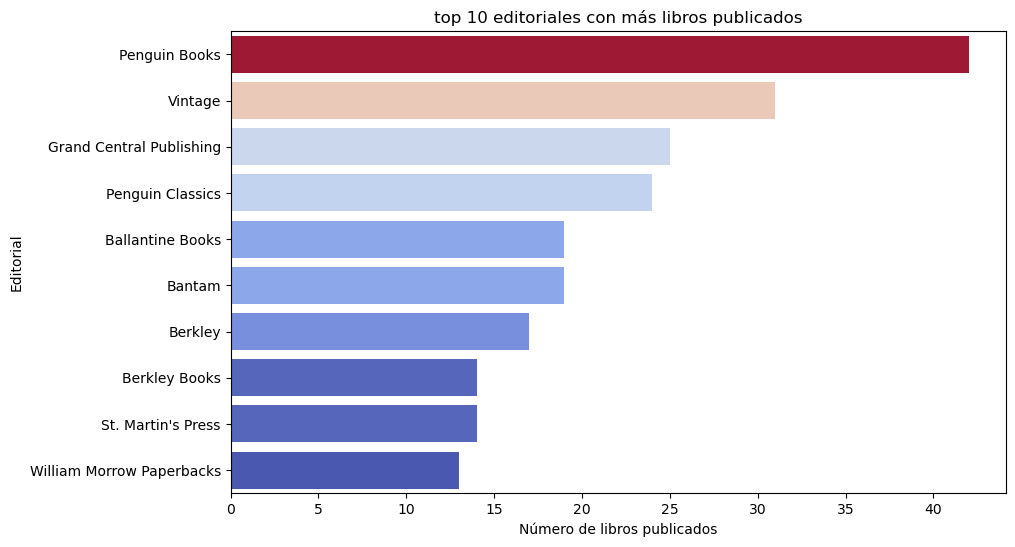

In [886]:
# Grafico top 10 editoriales con más libros publicados
plt.figure(figsize=(10,6))
sns.barplot(data=top10_editorial, x='num_books', y='publisher', palette='coolwarm', hue='num_books', legend=False)
plt.title('top 10 editoriales con más libros publicados')
plt.xlabel('Número de libros publicados')
plt.ylabel('Editorial')
plt.show()

### <a id='toc1_8_1_'></a>[Comentarios](#toc0_)

- Penguin Books destaca ampliamente como la editorial con mayor cantidad de libros publicados, superando por un margen considerable al resto de las editoriales del top 10 ello se suma que Penguin Books tiene direntes subdvisiones empresariales y una de ellas tambien se encuentra en el top 10.
- Vintage y Grand Central Publishing ocupan el segundo y tercer lugar respectivamente, pero con una diferencia notable respecto a Penguin Books, lo que indica una concentración significativa de publicaciones en la editorial líder.
- El resto de las editoriales, como Penguin Classics, Ballantine Books, Bantam y Berkley, presentan cifras similares entre sí, lo que sugiere una competencia más equilibrada en los puestos intermedios.
- La diferencia entre la editorial líder y las demás es considerable, lo que podría indicar una mayor capacidad de producción, catálogo más amplio o mayor presencia en el mercado por parte de Penguin Books.
- La diversidad de editoriales en el top 10 muestra que, aunque hay una editorial dominante, existe una oferta variada de publicaciones provenientes de diferentes casas editoriales, lo que puede enriquecer la experiencia de los lectores.
- Las editoriales en los últimos lugares del top 10 (como William Morrow Paperbacks y St. Martin’s Press) tienen una cantidad de libros publicados significativamente menor, lo que podría indicar un enfoque más especializado o menor volumen de publicaciones. 

## <a id='toc1_9_'></a>[Autores con la calificación promedio más alta por libros](#toc0_)

In [887]:
# Autores con la calificación promedio más alta por libros con mas de 50 calificaciones
authors_avg_rating = get_data('''SELECT authors.author,
                                        AVG(sub.avg_rating) AS author_avg_rating
                              FROM ( 
                                    SELECT books.book_id,books.author_id, AVG(ratings.rating) AS avg_rating
                                    FROM books
                                    JOIN ratings ON books.book_id= ratings.book_id
                                    GROUP BY books.book_id, books.author_id
                                    HAVING COUNT(ratings.rating)> 50) AS sub
                              JOIN authors ON sub.author_id = authors.author_id
                              GROUP BY authors.author;''')

top10_authors=authors_avg_rating.sort_values(by='author_avg_rating', ascending=False).head(10).reset_index(drop=True)
print(top10_authors)

                                              author  author_avg_rating
0                         J.K. Rowling/Mary GrandPré           4.283844
1                  Markus Zusak/Cao Xuân Việt Khương           4.264151
2                                     J.R.R. Tolkien           4.258446
3                                  Louisa May Alcott           4.192308
4                                       Rick Riordan           4.080645
5                                    William Golding           3.901408
6                                      J.D. Salinger           3.825581
7           Paulo Coelho/Alan R. Clarke/Özdemir İnce           3.789474
8  William Shakespeare/Paul Werstine/Barbara A. M...           3.787879
9                                          Dan Brown           3.754540


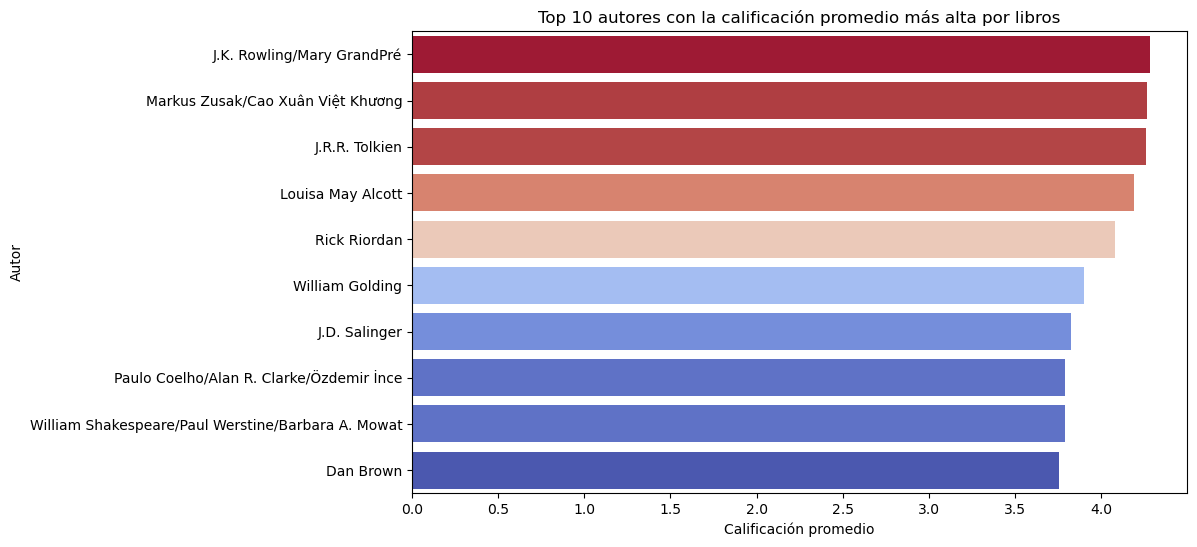

In [888]:
# Grafico top 10 autores con la calificación promedio más alta por libros
plt.figure(figsize=(10,6))
sns.barplot(data=top10_authors, x='author_avg_rating', y='author', palette='coolwarm', hue='author_avg_rating', legend=False)
plt.title('Top 10 autores con la calificación promedio más alta por libros')
plt.xlabel('Calificación promedio')
plt.ylabel('Autor')
plt.show()

### <a id='toc1_9_1_'></a>[Comentarios](#toc0_)
- J.K. Rowling/Mary GrandPré encabezan la lista, lo que indica que los libros de la saga de Harry Potter (ilustrados por Mary GrandPré) no solo son populares, sino que también son altamente valorados por los lectores. Esto refleja tanto la calidad literaria como el impacto cultural de la serie.
- Markus Zusak/Cao Xuân Việt Khương y J.R.R. Tolkien ocupan los siguientes lugares, mostrando que tanto obras contemporáneas como clásicas pueden alcanzar altos niveles de satisfacción entre los lectores. Tolkien, autor de "El Señor de los Anillos", es un referente en la literatura fantástica, mientras que Zusak es conocido por "La ladrona de libros".
- Louisa May Alcott y Rick Riordan también destacan. Alcott, autora de "Mujercitas", sigue siendo relevante y apreciada a pesar del paso del tiempo. Rick Riordan, con sus sagas de mitología juvenil, demuestra gran aceptación entre el público joven.
- William Golding y J.D. Salinger aparecen en la mitad superior del ranking, lo que sugiere que sus obras ("El señor de las moscas" y "El guardián entre el centeno", respectivamente) mantienen un alto prestigio y valoración crítica.
- Paulo Coelho/Alan R. Clarke/Özdemir İnce y William Shakespeare/Paul Werstine/Barbara A. Mowat muestran que tanto autores contemporáneos como clásicos universales pueden recibir altas calificaciones, especialmente cuando sus obras son presentadas en ediciones cuidadas o traducidas por expertos.
- Dan Brown cierra el top 10, lo que indica que sus thrillers, aunque a veces polémicos en la crítica literaria, son muy bien recibidos por el público general.

A partir del análisis, se destaca que la calificación promedio de los autores en el top 10 supera los 3.5 puntos. Este dato indica que, aunque existen autores que lideran el ranking, la diversidad de géneros y nichos representados por estos autores ofrece una amplia variedad de opciones para los lectores. Estos resultados permiten visualizar claramente el potencial para desarrollar nuevos productos digitales enfocados en las preferencias y tendencias identificadas en la plataforma.



## <a id='toc1_10_'></a>[Número promedio de reseñas de texto entre los usuarios que calificaron más de 50 libros](#toc0_)

In [889]:
# Consulta del número promedio de reseñas de texto entre los usuarios que calificaron más de 50 libros
avg_text_reviews = get_data(''' WITH user_review_ratings AS (
                                    SELECT username
                                    FROM ratings
                                    GROUP BY username
                                    HAVING COUNT(rating_id)>50)
                                
                                SELECT AVG(num_reviews) AS avg_text_reviews
                                FROM (
                                     SELECT user_review_ratings.username,
                                     COUNT(reviews.review_id) AS num_reviews
                                     FROM user_review_ratings
                                     LEFT JOIN reviews ON user_review_ratings.username = reviews.username
                                     GROUP BY user_review_ratings.username) AS user_reviews;''')

print(avg_text_reviews)

users_text_reviews= get_data('''WITH users_with_50_ratings AS (
                                SELECT username
                                FROM ratings
                                GROUP BY username
                                HAVING COUNT(rating_id) > 50)                                   
                            SELECT
                                u.username,
                                COUNT(r.review_id) AS num_reviews
                                FROM users_with_50_ratings u
                                LEFT JOIN reviews r ON u.username = r.username
                                GROUP BY u.username
                                ORDER BY num_reviews DESC;''')
print(users_text_reviews)


   avg_text_reviews
0         24.333333
         username  num_reviews
0     sfitzgerald           28
1      martinadam           27
2       richard89           26
3  jennifermiller           25
4          paul88           22
5          xdavis           18


       num_reviews
count   160.000000
mean     17.456250
std       3.998186
min       5.000000
25%      15.000000
50%      17.000000
75%      19.000000
max      29.000000
             username  num_reviews
0         abbottjames           18
1        abigailmoore           18
2        adamsabigail           15
3            alison92           14
4               amy97           25
..                ...          ...
155  yvonnevillarreal           13
156            yweeks           15
157         zjohnston           14
158           znelson           12
159             zross           20

[160 rows x 2 columns]


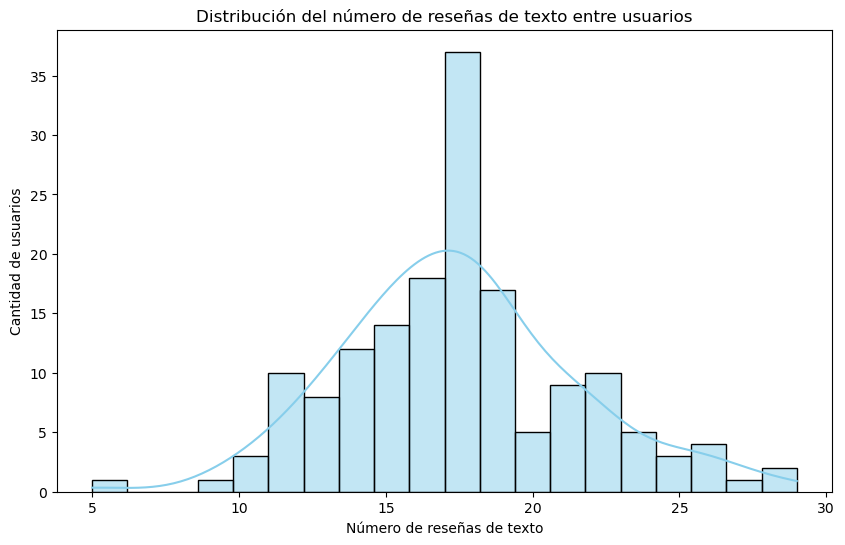

In [890]:
user_reviews = reviews.groupby('username')['review_id'].nunique().reset_index(name='num_reviews')
print(user_reviews.describe())
print(user_reviews)
plt.figure(figsize=(10, 6))
sns.histplot(user_reviews['num_reviews'], bins=20, kde=True, color='skyblue')
plt.title('Distribución del número de reseñas de texto entre usuarios')
plt.xlabel('Número de reseñas de texto')
plt.ylabel('Cantidad de usuarios')
plt.show()

### <a id='toc1_10_1_'></a>[Comentarios](#toc0_)
- Tras el filtrado de la información, se identificó que únicamente un grupo reducido de usuarios ha calificado más de 50 libros y, simultáneamente, ha dejado reseñas escritas. Este comportamiento refleja una limitada interacción crítica dentro del segmento de usuarios más activos, con un promedio de 24.3 reseñas por usuario en este subconjunto.

- El análisis de la distribución del número de reseñas de texto, representado mediante un histograma, evidencia una tendencia aproximadamente normal, con una media de 17 reseñas por usuario. Estos resultados sugieren que, en términos generales, la mayoría de los usuarios que asignan calificaciones a los libros no suelen complementar su evaluación con comentarios escritos. Esta baja proporción de reseñas textuales representa un área de oportunidad para la plataforma, que podría considerar el desarrollo de mecanismos o incentivos orientados a fomentar una mayor participación en la generación de contenido crítico y opiniones detalladas sobre los libros leídos, contribuyendo así a enriquecer la experiencia y el valor de la comunidad lectora.

---

# <a id='toc2_'></a>[Conclusiones](#toc0_)

- **Crecimiento editorial:** La mayoría de los libros analizados fueron publicados a partir del año 2000, evidenciando un crecimiento significativo en la producción editorial durante este periodo. Se identificaron 819 nuevos libros publicados después del 1 de enero de 2000.
- **Tendencias de publicación:** El número de lanzamientos de libros por año mostró un crecimiento casi lineal hasta 2006, seguido de una caída abrupta de más del 70% a partir de 2007. Este fenómeno sugiere la necesidad de investigar posibles causas, como cambios en la industria, la aparición de plataformas digitales o variaciones en las preferencias de los lectores.
- **Popularidad y calidad de los libros:** Los libros con mayor número de reseñas tienden a tener una base estadística sólida, lo que permite evaluar de manera confiable su calidad. El libro más destacado supera las 1000 reseñas, mientras que el resto del top 10 presenta una diferencia significativa en el volumen de participación.
- **Calificaciones positivas:** Los libros presentes en el top 10 mantienen calificaciones promedio entre 3.5 y 4.5, lo que indica una tendencia general de valoración positiva por parte de los usuarios.
- **Editoriales líderes:** Penguin Books sobresale como la editorial con mayor cantidad de libros publicados, seguida por Vintage y Grand Central Publishing. La presencia de varias subdivisiones de Penguin Books en el top 10 refuerza su liderazgo y capacidad de producción. Sin embargo, la diversidad de editoriales en el ranking enriquece la oferta para los lectores.
- **Autores destacados:** El top 10 de autores mejor calificados incluye tanto figuras contemporáneas como clásicas, abarcando una amplia variedad de géneros y estilos. Esto demuestra que la plataforma atrae a lectores con intereses diversos y que la calidad literaria es reconocida independientemente de la época o el género.
- **Participación de los usuarios:** Solo un grupo reducido de usuarios ha calificado más de 50 libros y dejado reseñas escritas, con un promedio de 24.3 reseñas por usuario en este segmento. El análisis de la distribución de reseñas muestra una media de 17 reseñas por usuario, lo que evidencia una baja proporción de comentarios textuales en relación con las calificaciones otorgadas.
- **Oportunidad de mejora:** La limitada interacción crítica representa un área de oportunidad para la plataforma. Fomentar la generación de reseñas de texto puede enriquecer la experiencia de la comunidad lectora y aportar mayor valor a la plataforma, tanto para usuarios como para editoriales y autores.

---

# <a id='toc3_'></a>[Propuesta de valor para un nuevo producto digital](#toc0_)


### <a id='toc3_1_1_'></a>[Descripción general](#toc0_)

A partir del análisis de la base de datos y de los patrones de comportamiento identificados en la plataforma, se propone el desarrollo de un **Ligeros cambios en la plataforma orientado a la promoción de la interacción del usuario y la personalización de la experiencia lectora**. Este producto estará enfocado en incentivar la interaccion del usuario, mejorar la visibilidad de libros y autores destacados, ofrecer recomendaciones personalizadas basadas en datos reales de uso y preferencias de los usuarios.

---

### <a id='toc3_1_2_'></a>[Objetivos del nuevo producto](#toc0_)

1. **Fomentar la participación activa de los usuarios:**  
   Implementar mecanismos de gamificación, recompensas digitales o reconocimientos para motivar a los usuarios a escribir reseñas sobre los libros que califican, incrementando así la cantidad y calidad del contenido generado por la comunidad.

2. **Personalizar la experiencia lectora:**  
   Desarrollar un sistema de recomendaciones inteligentes que utilice tanto las calificaciones como las reseñas de texto para sugerir libros, autores y editoriales alineados con los intereses y hábitos de lectura de cada usuario.

3. **Visibilizar la diversidad editorial y autoral:**  
   Crear espacios destacados dentro de la plataforma para editoriales y autores con alto desempeño, así como para aquellos que representen géneros o nichos menos explorados, promoviendo una oferta editorial variada y enriquecedora.

4. **Monitorear y analizar tendencias del mercado:**  
   Incorporar herramientas de análisis que permitan identificar cambios en la producción editorial, preferencias de los lectores y evolución de la participación de los usuarios, facilitando la toma de decisiones estratégicas y la adaptación continua del producto.

---